AGAIN
# New Section

In [1]:
# Check GPU availability
import torch
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Install all dependencies
!pip install -q torch torchvision opencv-python-headless numpy Pillow matplotlib scipy scikit-image pandas tqdm
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

print("✓ All dependencies installed!")


GPU Available: True
GPU Name: Tesla T4
  Preparing metadata (setup.py) ... done
✓ All dependencies installed!


In [2]:
import os

# Clone Dr.SAM repository
if not os.path.exists('Dr.SAM'):
    !git clone https://github.com/vazgenzohranyan/Dr.SAM.git
    print("✓ Repository cloned")
else:
    print("✓ Repository already exists")

# Change to project directory
%cd Dr.SAM

# Create checkpoints directory
!mkdir -p checkpoints

# Download SAM checkpoint (ViT-H model - largest and best)
if not os.path.exists('checkpoints/sam_vit_h_4b8939.pth'):
    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -P checkpoints/
    print("✓ SAM checkpoint downloaded")
else:
    print("✓ SAM checkpoint already exists")


Cloning into 'Dr.SAM'...
remote: Enumerating objects: 123, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 123 (delta 48), reused 99 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (123/123), 1.21 MiB | 4.79 MiB/s, done.
Resolving deltas: 100% (48/48), done.
✓ Repository cloned
/content/Dr.SAM
--2026-02-09 04:29:53--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.81, 13.249.182.39, 13.249.182.62, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.81|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘checkpoints/sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   183MB/s    in 14s     

2026-02-09 04:30:06 (181 MB/s) - ‘checkpoints/sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]

✓ SA

In [3]:
import os

# Clone Dr.SAM repository
if not os.path.exists('Dr.SAM'):
    !git clone https://github.com/vazgenzohranyan/Dr.SAM.git
    print("✓ Repository cloned")
else:
    print("✓ Repository already exists")

# Change to project directory
%cd Dr.SAM

# Create checkpoints directory
!mkdir -p checkpoints

# Download SAM checkpoint (ViT-H model - largest and best)
if not os.path.exists('checkpoints/sam_vit_h_4b8939.pth'):
    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -P checkpoints/
    print("✓ SAM checkpoint downloaded")
else:
    print("✓ SAM checkpoint already exists")


Cloning into 'Dr.SAM'...
remote: Enumerating objects: 123, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 123 (delta 48), reused 99 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (123/123), 1.21 MiB | 3.85 MiB/s, done.
Resolving deltas: 100% (48/48), done.
✓ Repository cloned
/content/Dr.SAM/Dr.SAM
--2026-02-09 04:30:07--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.81, 13.249.182.39, 13.249.182.62, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.81|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘checkpoints/sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G  98.5MB/s    in 18s     

2026-02-09 04:30:26 (132 MB/s) - ‘checkpoints/sam_vit_h_4b8939.pth’ saved [2564550879/2564550879

In [4]:
# Create data directories
!mkdir -p data/images data/masks

# Download the Dr.SAM angiography dataset
# Note: Replace with actual dataset URL from the repository
!pip install -q gdown
!gdown https://drive.google.com/uc?id=1TjxEJUD4VC_SAPcqdNVybsKRb_xW-Bze -O data.zip
!unzip data.zip -d data/

print("✓ Dataset downloaded and extracted")
print(f"Images: {len(os.listdir('data/images'))}")
print(f"Masks: {len(os.listdir('data/masks'))}")


Downloading...
From (original): https://drive.google.com/uc?id=1TjxEJUD4VC_SAPcqdNVybsKRb_xW-Bze
From (redirected): https://drive.google.com/uc?id=1TjxEJUD4VC_SAPcqdNVybsKRb_xW-Bze&confirm=t&uuid=35f66d02-6bbb-4bb5-96c5-dc8afd143c32
To: /content/Dr.SAM/Dr.SAM/data.zip
100% 35.6M/35.6M [00:01<00:00, 29.6MB/s]
Archive:  data.zip
  inflating: data/images/63.jpg      
  inflating: data/images/189.jpg     
  inflating: data/images/77.jpg      
  inflating: data/images/162.jpg     
  inflating: data/images/176.jpg     
  inflating: data/images/88.jpg      
  inflating: data/images/348.jpg     
  inflating: data/images/360.jpg     
  inflating: data/images/406.jpg     
  inflating: data/images/412.jpg     
  inflating: data/images/374.jpg     
  inflating: data/images/228.jpg     
  inflating: data/images/214.jpg     
  inflating: data/images/200.jpg     
  inflating: data/images/201.jpg     
  inflating: data/images/215.jpg     
  inflating: data/images/229.jpg     
  inflating: data/images/

In [5]:
import torch
import numpy as np
import cv2
import json
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt
from PIL import Image

# Initialize SAM model
device = "cuda" if torch.cuda.is_available() else "cpu"
sam_checkpoint = "checkpoints/sam_vit_h_4b8939.pth"
model_type = "vit_h"

print("Loading SAM model...")
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)
print(f"✓ SAM model loaded on {device}")


Loading SAM model...
✓ SAM model loaded on cuda


In [6]:
def segment_vessel(predictor, image, bbox, point_coords=None):
    """
    Stage 1: Vessel Segmentation using SAM
    """
    # Set image for SAM
    predictor.set_image(image)

    # Use bounding box prompt
    bbox_array = np.array(bbox)

    # Add point prompts if provided
    if point_coords is not None:
        point_labels = np.ones(len(point_coords))
        masks, scores, logits = predictor.predict(
            point_coords=np.array(point_coords),
            point_labels=point_labels,
            box=bbox_array,
            multimask_output=False
        )
    else:
        masks, scores, logits = predictor.predict(
            box=bbox_array,
            multimask_output=False
        )

    return masks[0], scores[0]

def estimate_diameter(mask):
    """
    Stage 2: Centerline Detection and Diameter Estimation
    """
    # Extract skeleton (centerline)
    skeleton = skeletonize(mask > 0)

    # Calculate distance transform
    distance_map = distance_transform_edt(mask)

    # Get diameters along centerline
    centerline_coords = np.argwhere(skeleton)
    diameters = []

    for coord in centerline_coords:
        diameter = distance_map[coord[0], coord[1]] * 2
        diameters.append(diameter)

    return skeleton, centerline_coords, np.array(diameters)

def detect_anomalies(diameters, threshold_stenosis=2.0, threshold_aneurysm=2.0):
    """
    Stage 3: Anomaly Detection (Stenosis and Aneurysm)
    """
    if len(diameters) == 0:
        return [], []

    mean_diameter = np.mean(diameters)
    std_diameter = np.std(diameters)

    stenosis_threshold = mean_diameter - threshold_stenosis * std_diameter
    aneurysm_threshold = mean_diameter + threshold_aneurysm * std_diameter

    stenosis_indices = np.where(diameters < stenosis_threshold)[0]
    aneurysm_indices = np.where(diameters > aneurysm_threshold)[0]

    return stenosis_indices, aneurysm_indices

def visualize_results(image, mask, skeleton, centerline_coords, diameters,
                      stenosis_indices, aneurysm_indices):
    """
    Visualize all Dr.SAM results
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Original image
    axes[0, 0].imshow(image)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    # Segmentation mask
    axes[0, 1].imshow(image)
    axes[0, 1].imshow(mask, alpha=0.5, cmap='jet')
    axes[0, 1].set_title('Vessel Segmentation')
    axes[0, 1].axis('off')

    # Centerline
    axes[0, 2].imshow(image)
    axes[0, 2].imshow(skeleton, alpha=0.7, cmap='hot')
    axes[0, 2].set_title('Centerline Detection')
    axes[0, 2].axis('off')

    # Diameter distribution
    if len(diameters) > 0:
        axes[1, 0].hist(diameters, bins=30, color='blue', alpha=0.7)
        axes[1, 0].axvline(np.mean(diameters), color='red', linestyle='--', label='Mean')
        axes[1, 0].set_title('Diameter Distribution')
        axes[1, 0].set_xlabel('Diameter (pixels)')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].legend()

    # Anomaly visualization
    axes[1, 1].imshow(image)
    axes[1, 1].imshow(mask, alpha=0.3, cmap='gray')

    # Mark stenosis (red) and aneurysm (blue)
    if len(stenosis_indices) > 0:
        stenosis_coords = centerline_coords[stenosis_indices]
        axes[1, 1].scatter(stenosis_coords[:, 1], stenosis_coords[:, 0],
                          c='red', s=50, marker='x', label='Stenosis')

    if len(aneurysm_indices) > 0:
        aneurysm_coords = centerline_coords[aneurysm_indices]
        axes[1, 1].scatter(aneurysm_coords[:, 1], aneurysm_coords[:, 0],
                          c='blue', s=50, marker='o', label='Aneurysm')

    axes[1, 1].set_title('Anomaly Detection')
    axes[1, 1].legend()
    axes[1, 1].axis('off')

    # Summary statistics
    axes[1, 2].axis('off')
    summary_text = f"""
    Summary Statistics:

    Mean Diameter: {np.mean(diameters):.2f} px
    Std Diameter: {np.std(diameters):.2f} px
    Min Diameter: {np.min(diameters):.2f} px
    Max Diameter: {np.max(diameters):.2f} px

    Anomalies Detected:
    Stenosis: {len(stenosis_indices)}
    Aneurysm: {len(aneurysm_indices)}
    """
    axes[1, 2].text(0.1, 0.5, summary_text, fontsize=12,
                   verticalalignment='center', family='monospace')
    axes[1, 2].set_title('Statistics')

    plt.tight_layout()
    plt.show()

print("✓ Dr.SAM pipeline functions defined")


✓ Dr.SAM pipeline functions defined


Running Dr.SAM pipeline...
✓ Segmentation complete (confidence: 0.748)
✓ Diameter estimation complete (1604 centerline points)
✓ Anomaly detection complete
  - Stenosis detected: 0
  - Aneurysm detected: 33


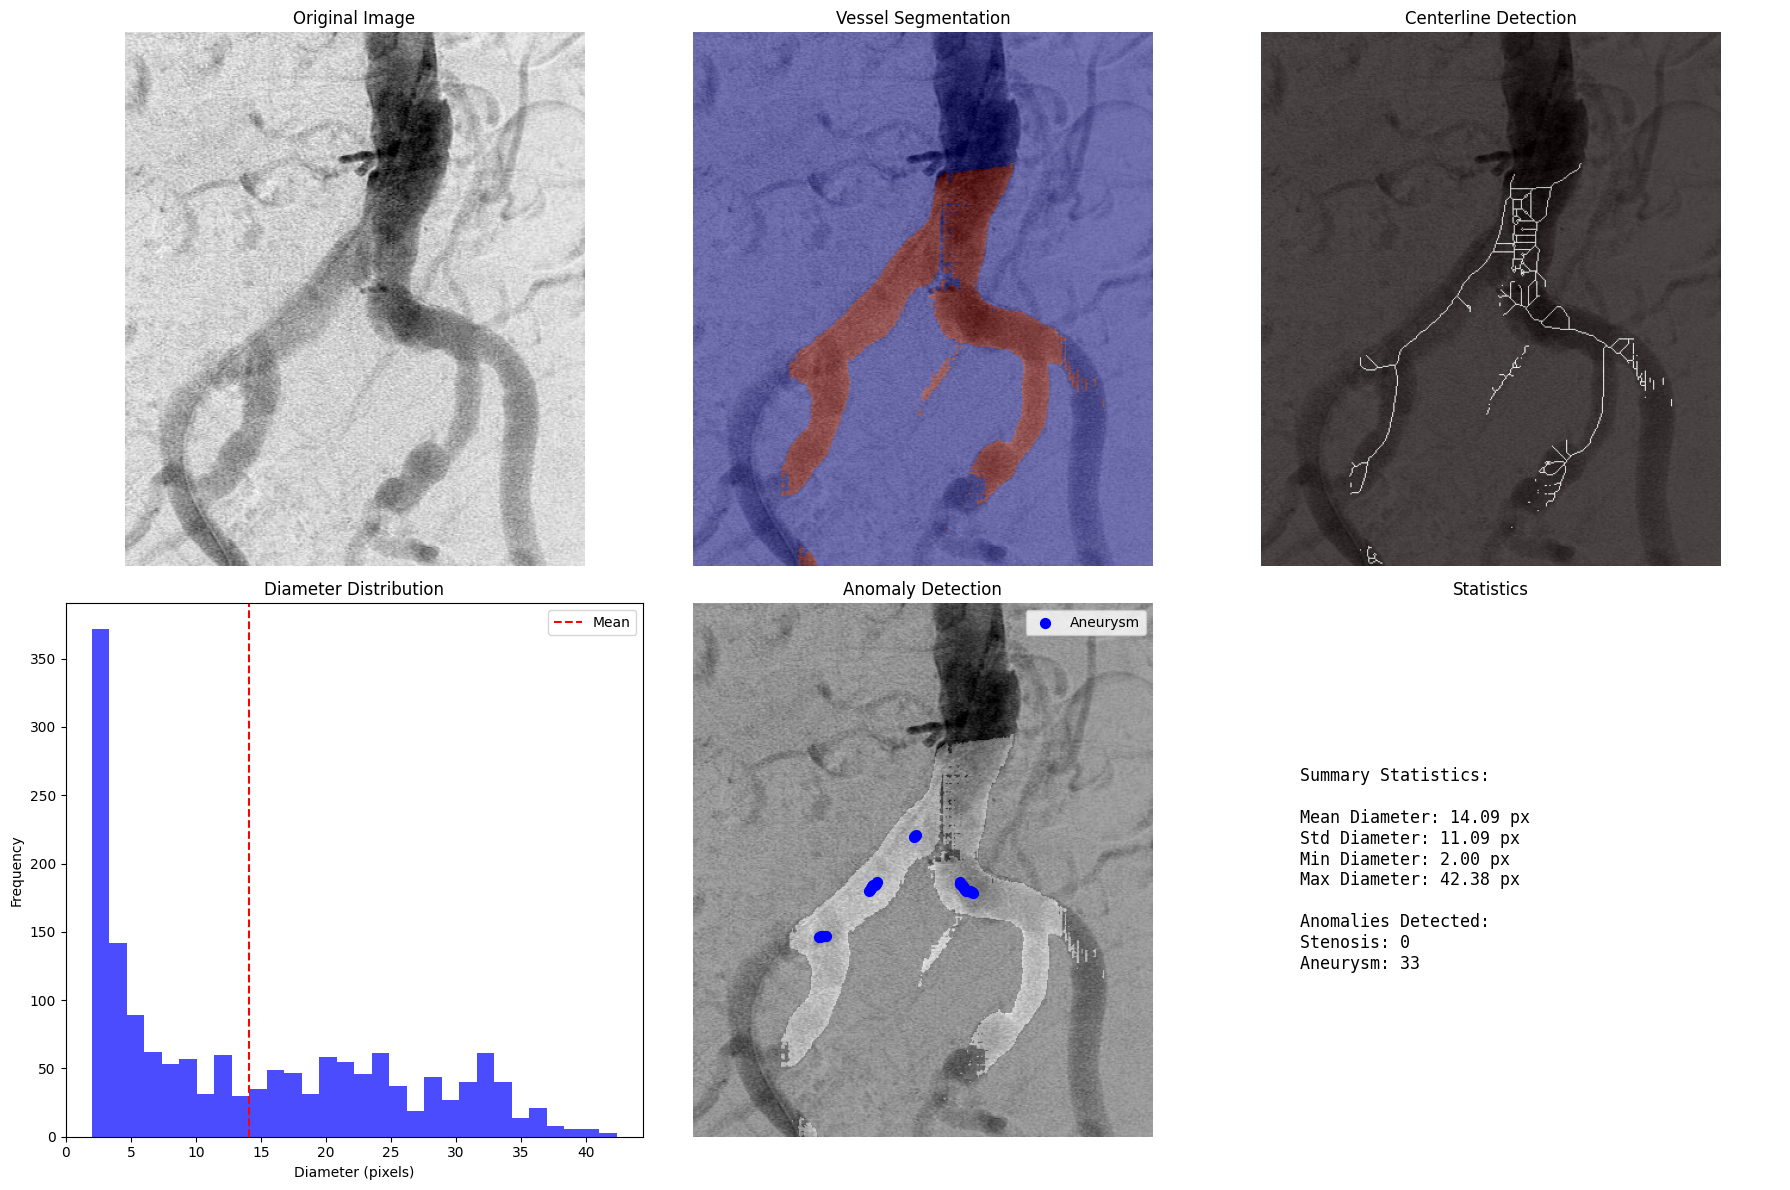

In [7]:
# Load a single image for testing
image_path = 'data/images/1.jpg'  # Replace with actual image
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Define bounding box manually or load from metadata
# Format: [x_min, y_min, x_max, y_max]
bbox = [100, 100, 500, 500]  # Adjust based on your image

# Optional: Define point prompts (center of vessel)
point_coords = [[300, 300]]  # Adjust based on your image

print("Running Dr.SAM pipeline...")

# Stage 1: Segmentation
mask, score = segment_vessel(predictor, image_rgb, bbox, point_coords)
print(f"✓ Segmentation complete (confidence: {score:.3f})")

# Stage 2: Diameter Estimation
skeleton, centerline_coords, diameters = estimate_diameter(mask)
print(f"✓ Diameter estimation complete ({len(diameters)} centerline points)")

# Stage 3: Anomaly Detection
stenosis_indices, aneurysm_indices = detect_anomalies(diameters)
print(f"✓ Anomaly detection complete")
print(f"  - Stenosis detected: {len(stenosis_indices)}")
print(f"  - Aneurysm detected: {len(aneurysm_indices)}")

# Visualize results
visualize_results(image_rgb, mask, skeleton, centerline_coords, diameters,
                 stenosis_indices, aneurysm_indices)


In [11]:
# Load metadata if available
metadata_path = 'data/metadata.json'

# Function to convert bbox from [x, y, w, h] to [x_min, y_min, x_max, y_max]
def convert_bbox(bbox):
    """Convert from [x, y, width, height] to [x_min, y_min, x_max, y_max]"""
    x, y, w, h = bbox
    return [x, y, x + w, y + h]

if os.path.exists(metadata_path):
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)

    print(f"Processing {len(metadata)} images from metadata...")

    results = []

    for idx, entry in enumerate(metadata[:5]):  # Process first 5 for demo
        image_id = entry.get('image_id', f'image_{idx}')

        # Get the list of bounding boxes for the current image
        bboxes_list = entry.get('bboxes', [])

        # Check if there are any bounding boxes for this image
        if not bboxes_list:
            print(f"⚠ No bounding boxes found for image {image_id}. Skipping.")
            continue

        # Take the first bounding box from the list and convert it to the expected format
        bbox_xywh = bboxes_list[0]
        bbox = convert_bbox(bbox_xywh)

        # Load image
        img_path = f'data/images/{image_id}.jpg'
        if not os.path.exists(img_path):
            print(f"⚠ Image not found: {img_path}")
            continue

        image = cv2.imread(img_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Run pipeline
        mask, score = segment_vessel(predictor, image_rgb, bbox)
        skeleton, centerline_coords, diameters = estimate_diameter(mask)
        stenosis_indices, aneurysm_indices = detect_anomalies(diameters)

        # Store results
        results.append({
            'image_id': image_id,
            'mean_diameter': float(np.mean(diameters)),
            'stenosis_count': len(stenosis_indices),
            'aneurysm_count': len(aneurysm_indices),
            'confidence': float(score)
        })

        print(f"✓ Processed {image_id}")

    # Save results
    with open('results.json', 'w') as f:
        json.dump(results, f, indent=2)

    print(f"\n✓ Batch processing complete! Results saved to results.json")
else:
    print("⚠ metadata.json not found. Use manual bbox definition above.")

Processing 500 images from metadata...
✓ Processed 1
✓ Processed 2
✓ Processed 3
✓ Processed 4
✓ Processed 5

✓ Batch processing complete! Results saved to results.json


In [12]:
# Save segmentation masks
output_dir = 'outputs'
!mkdir -p {output_dir}/masks {output_dir}/visualizations

# Export masks and visualizations
print("Exporting results...")

# Save mask as PNG
cv2.imwrite(f'{output_dir}/masks/predicted_mask.png', (mask * 255).astype(np.uint8))

# Save overlay visualization
overlay = image_rgb.copy()
overlay[mask > 0] = overlay[mask > 0] * 0.5 + np.array([255, 0, 0]) * 0.5
cv2.imwrite(f'{output_dir}/visualizations/overlay.png',
            cv2.cvtColor(overlay.astype(np.uint8), cv2.COLOR_RGB2BGR))

print("✓ Results exported to 'outputs' directory")

# Download results to local machine
from google.colab import files
files.download('results.json')


Exporting results...
✓ Results exported to 'outputs' directory


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
import json
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Load your metadata
with open('/content/Dr.SAM/Dr.SAM/data/metadata.json', 'r') as f:  # or 'metadata.json'
    metadata = json.load(f)

print(f"✓ Loaded {len(metadata)} images with annotations")

# Function to convert bbox from [x, y, w, h] to [x_min, y_min, x_max, y_max]
def convert_bbox(bbox):
    """Convert from [x, y, width, height] to [x_min, y_min, x_max, y_max]"""
    x, y, w, h = bbox
    return [x, y, x + w, y + h]

# Display metadata structure
sample = metadata[0]
print("\nSample metadata structure:")
print(f"Image ID: {sample['image_id']}")
print(f"Number of vessels: {len(sample['bboxes'])}")
print(f"Stenosis points: {sample['anomalies']['stenosis']}")
print(f"Aneurysm points: {sample['anomalies']['aneurysm']}")
print(f"First bbox (x,y,w,h): {sample['bboxes'][0]}")
print(f"Converted to (x1,y1,x2,y2): {convert_bbox(sample['bboxes'][0])}")


✓ Loaded 500 images with annotations

Sample metadata structure:
Image ID: 1
Number of vessels: 3
Stenosis points: [[270, 351]]
Aneurysm points: [[229, 388], [253, 361]]
First bbox (x,y,w,h): [158, 11, 134, 192]
Converted to (x1,y1,x2,y2): [158, 11, 292, 203]


In [14]:
# Select an image to process
img_idx = 10  # Change this to process different images
entry = metadata[img_idx]
image_id = entry['image_id']

# Load image (adjust path based on your data location)
# Assuming images are named like '1.png', '2.png', etc.
img_path = f'data/images/{image_id}.jpg'  # or .jpg based on your dataset

if not os.path.exists(img_path):
    print(f"⚠ Image not found: {img_path}")
    print("Please update the image path according to your dataset structure")
else:
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    print(f"\n{'='*60}")
    print(f"Processing Image ID: {image_id}")
    print(f"Image shape: {image_rgb.shape}")
    print(f"Number of vessels: {len(entry['bboxes'])}")
    print(f"{'='*60}\n")

    # Process each vessel in the image
    all_masks = []
    all_results = []

    for vessel_idx, bbox_xywh in enumerate(entry['bboxes']):
        print(f"\n--- Vessel {vessel_idx + 1}/{len(entry['bboxes'])} ---")

        # Convert bbox format
        bbox = convert_bbox(bbox_xywh)
        print(f"Bounding box: {bbox}")

        # Stage 1: Segmentation
        mask, score = segment_vessel(predictor, image_rgb, bbox)
        print(f"✓ Segmentation confidence: {score:.3f}")

        # Stage 2: Diameter Estimation
        skeleton, centerline_coords, diameters = estimate_diameter(mask)
        print(f"✓ Centerline points: {len(diameters)}")

        if len(diameters) > 0:
            print(f"  Mean diameter: {np.mean(diameters):.2f} px")
            print(f"  Diameter range: [{np.min(diameters):.2f}, {np.max(diameters):.2f}] px")

            # Stage 3: Anomaly Detection
            stenosis_indices, aneurysm_indices = detect_anomalies(diameters)
            print(f"✓ Detected anomalies:")
            print(f"  Stenosis: {len(stenosis_indices)}")
            print(f"  Aneurysm: {len(aneurysm_indices)}")
        else:
            stenosis_indices, aneurysm_indices = [], []
            print("⚠ No centerline detected")

        # Store results
        all_masks.append(mask)
        all_results.append({
            'vessel_idx': vessel_idx,
            'bbox': bbox,
            'mask': mask,
            'skeleton': skeleton,
            'centerline_coords': centerline_coords,
            'diameters': diameters,
            'stenosis_indices': stenosis_indices,
            'aneurysm_indices': aneurysm_indices,
            'confidence': score
        })

    print(f"\n✓ Processed all {len(entry['bboxes'])} vessels in image {image_id}")



Processing Image ID: 11
Image shape: (448, 386, 3)
Number of vessels: 3


--- Vessel 1/3 ---
Bounding box: [160, 4, 250, 143]
✓ Segmentation confidence: 0.898
✓ Centerline points: 231
  Mean diameter: 30.60 px
  Diameter range: [2.00, 54.15] px
✓ Detected anomalies:
  Stenosis: 0
  Aneurysm: 0

--- Vessel 2/3 ---
Bounding box: [12, 133, 189, 427]
✓ Segmentation confidence: 0.830
✓ Centerline points: 388
  Mean diameter: 19.69 px
  Diameter range: [2.00, 29.73] px
✓ Detected anomalies:
  Stenosis: 36
  Aneurysm: 0

--- Vessel 3/3 ---
Bounding box: [188, 114, 339, 422]
✓ Segmentation confidence: 0.840
✓ Centerline points: 425
  Mean diameter: 18.51 px
  Diameter range: [2.00, 30.00] px
✓ Detected anomalies:
  Stenosis: 24
  Aneurysm: 0

✓ Processed all 3 vessels in image 11


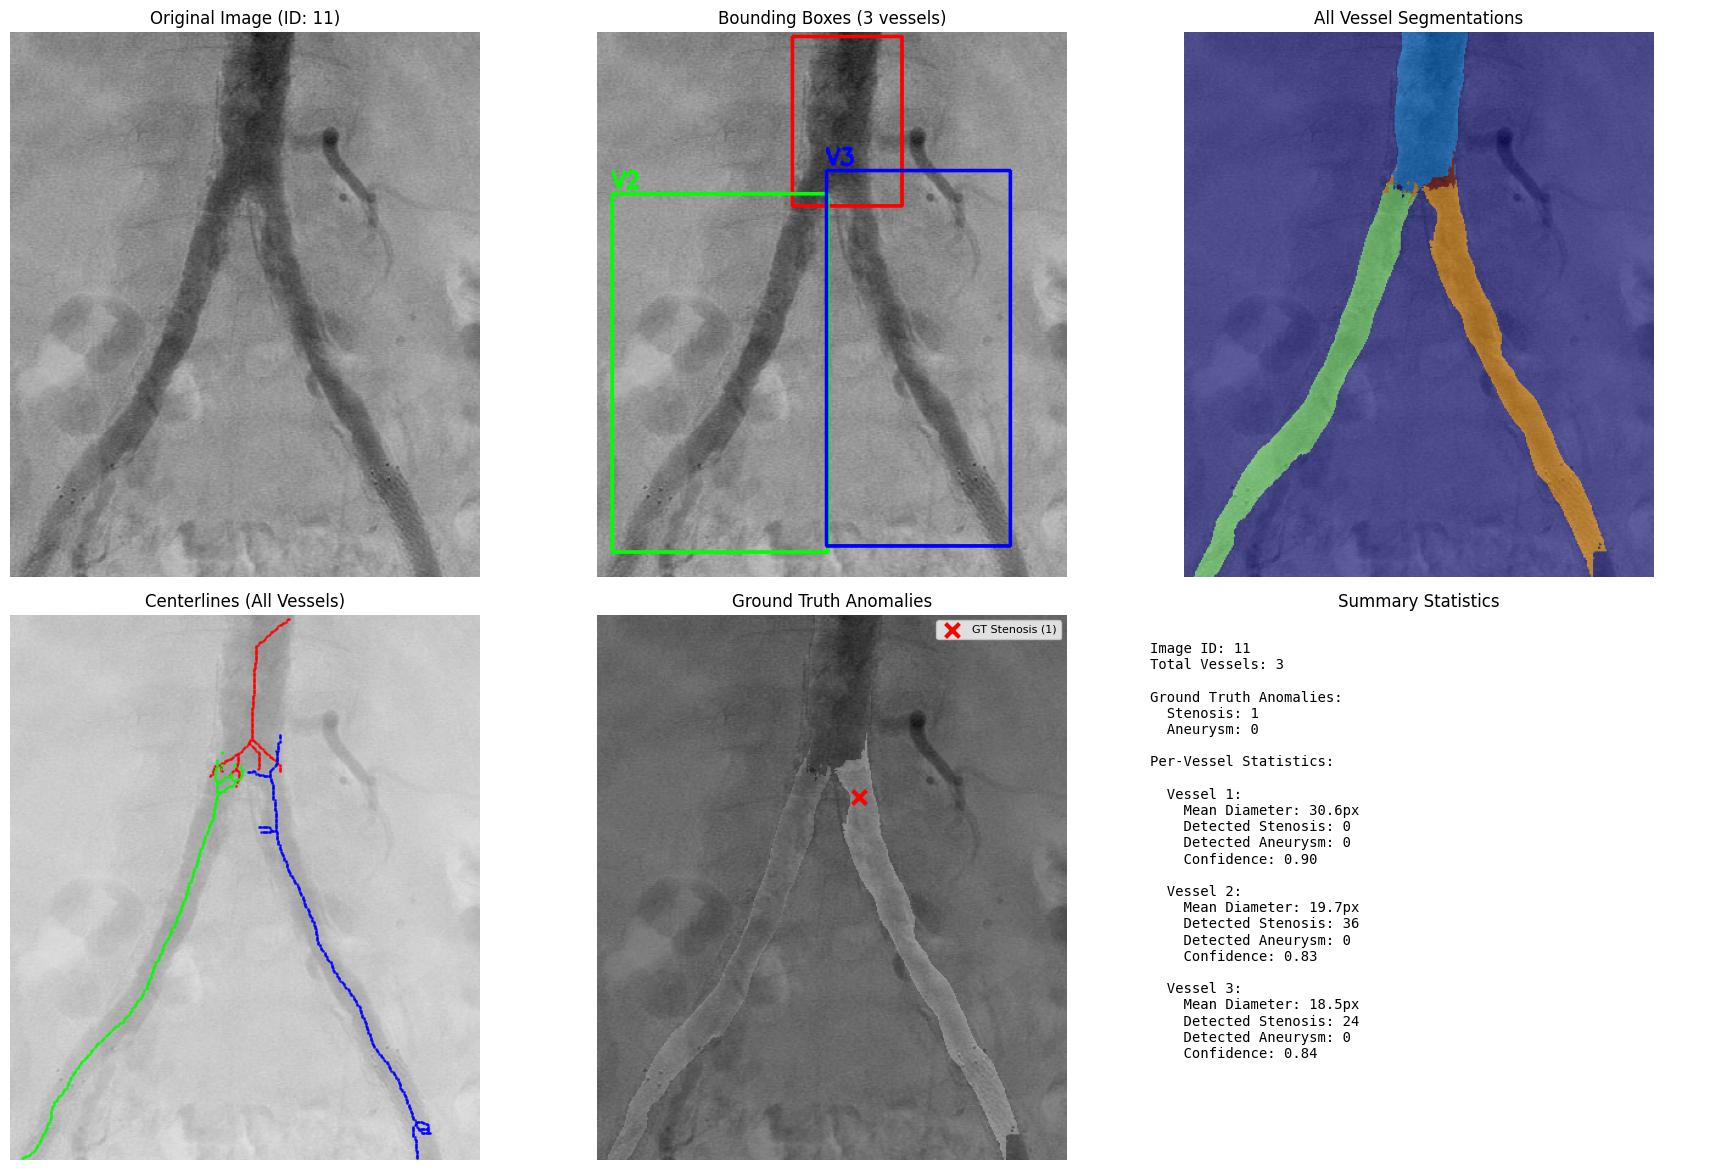


✓ Visualization saved to outputs/image_11_analysis.png


In [15]:
# Visualize all vessels together
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Original image
axes[0, 0].imshow(image_rgb)
axes[0, 0].set_title(f'Original Image (ID: {image_id})')
axes[0, 0].axis('off')

# Draw all bounding boxes
img_with_boxes = image_rgb.copy()
# Define colors for OpenCV (0-255 range)
cv2_colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]
# Define colors for Matplotlib scatter (0-1 range)
colors_for_plot = [tuple(val / 255.0 for val in rgb) for rgb in cv2_colors]

for idx, bbox_xywh in enumerate(entry['bboxes']):
    x, y, w, h = bbox_xywh
    color_cv2 = cv2_colors[idx % len(cv2_colors)]
    cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), color_cv2, 2)
    cv2.putText(img_with_boxes, f'V{idx+1}', (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_cv2, 2)

axes[0, 1].imshow(img_with_boxes)
axes[0, 1].set_title(f'Bounding Boxes ({len(entry["bboxes"])} vessels)')
axes[0, 1].axis('off')

# Combined segmentation masks
combined_mask = np.zeros_like(image_rgb[:, :, 0], dtype=float)
for idx, result in enumerate(all_results):
    combined_mask += result['mask'] * (idx + 1) / len(all_results)

axes[0, 2].imshow(image_rgb)
axes[0, 2].imshow(combined_mask, alpha=0.5, cmap='jet')
axes[0, 2].set_title('All Vessel Segmentations')
axes[0, 2].axis('off')

# Combined centerlines
axes[1, 0].imshow(image_rgb, alpha=0.5)
for idx, result in enumerate(all_results):
    if len(result['centerline_coords']) > 0:
        coords = result['centerline_coords']
        # Use the 0-1 range color for matplotlib scatter
        axes[1, 0].scatter(coords[:, 1], coords[:, 0], s=1,
                          color=colors_for_plot[idx % len(colors_for_plot)], alpha=0.7)
axes[1, 0].set_title('Centerlines (All Vessels)')
axes[1, 0].axis('off')

# Ground truth anomalies vs detected
axes[1, 1].imshow(image_rgb)
axes[1, 1].imshow(combined_mask, alpha=0.3, cmap='gray')

# Plot ground truth anomalies from metadata
gt_stenosis = entry['anomalies']['stenosis']
gt_aneurysm = entry['anomalies']['aneurysm']

if gt_stenosis:
    gt_sten_array = np.array(gt_stenosis)
    axes[1, 1].scatter(gt_sten_array[:, 0], gt_sten_array[:, 1],
                      color='red', s=100, marker='x', label=f'GT Stenosis ({len(gt_stenosis)})',
                      linewidths=3)

if gt_aneurysm:
    gt_aneu_array = np.array(gt_aneurysm)
    axes[1, 1].scatter(gt_aneu_array[:, 0], gt_aneu_array[:, 1],
                      color='blue', s=100, marker='o', label=f'GT Aneurysm ({len(gt_aneurysm)})',
                      linewidths=2)

axes[1, 1].set_title('Ground Truth Anomalies')
if gt_stenosis or gt_aneurysm: # Only show legend if there are anomalies to label
    axes[1, 1].legend(loc='upper right', fontsize=8)
axes[1, 1].axis('off')

# Statistics summary
axes[1, 2].axis('off')
summary_text = f"""Image ID: {image_id}
Total Vessels: {len(entry['bboxes'])}

Ground Truth Anomalies:
  Stenosis: {len(gt_stenosis)}
  Aneurysm: {len(gt_aneurysm)}

Per-Vessel Statistics:"""

for idx, result in enumerate(all_results):
    if len(result['diameters']) > 0:
        summary_text += f"""

  Vessel {idx+1}:
    Mean Diameter: {np.mean(result['diameters']):.1f}px
    Detected Stenosis: {len(result['stenosis_indices'])}
    Detected Aneurysm: {len(result['aneurysm_indices'])}
    Confidence: {result['confidence']:.2f}"""

axes[1, 2].text(0.05, 0.95, summary_text, fontsize=10,
               verticalalignment='top', family='monospace',
               transform=axes[1, 2].transAxes)
axes[1, 2].set_title('Summary Statistics')

plt.tight_layout()

# Ensure the 'outputs' directory exists before saving
!mkdir -p outputs

plt.savefig(f'outputs/image_{image_id}_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to outputs/image_{image_id}_analysis.png")


In [16]:
# Process all images in the dataset
all_image_results = []

# Process subset for testing (remove [:10] to process all)
for entry in metadata[:10]:
    image_id = entry['image_id']

    # Construct image path
    img_path = f'data/images/{image_id}.jpg'  # Adjust extension if needed

    if not os.path.exists(img_path):
        print(f"⚠ Skipping image {image_id}: file not found")
        continue

    # Load image
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    vessel_results = []

    # Process each vessel
    for vessel_idx, bbox_xywh in enumerate(entry['bboxes']):
        bbox = convert_bbox(bbox_xywh)

        try:
            # Run Dr.SAM pipeline
            mask, score = segment_vessel(predictor, image_rgb, bbox)
            skeleton, centerline_coords, diameters = estimate_diameter(mask)
            stenosis_indices, aneurysm_indices = detect_anomalies(diameters)

            vessel_results.append({
                'vessel_idx': vessel_idx,
                'mean_diameter': float(np.mean(diameters)) if len(diameters) > 0 else 0,
                'std_diameter': float(np.std(diameters)) if len(diameters) > 0 else 0,
                'centerline_points': len(diameters),
                'detected_stenosis': len(stenosis_indices),
                'detected_aneurysm': len(aneurysm_indices),
                'confidence': float(score)
            })
        except Exception as e:
            print(f"⚠ Error processing image {image_id}, vessel {vessel_idx}: {str(e)}")
            continue

    all_image_results.append({
        'image_id': image_id,
        'vessels': vessel_results,
        'gt_stenosis_count': len(entry['anomalies']['stenosis']),
        'gt_aneurysm_count': len(entry['anomalies']['aneurysm']),
        'total_vessels': len(entry['bboxes'])
    })

    print(f"✓ Processed image {image_id} ({len(vessel_results)}/{len(entry['bboxes'])} vessels)")

# Save results
with open('outputs/dr_sam_results.json', 'w') as f:
    json.dump(all_image_results, f, indent=2)

print(f"\n✓ Batch processing complete!")
print(f"✓ Processed {len(all_image_results)} images")
print(f"✓ Results saved to outputs/dr_sam_results.json")


✓ Processed image 1 (3/3 vessels)
✓ Processed image 2 (3/3 vessels)
✓ Processed image 3 (3/3 vessels)
✓ Processed image 4 (3/3 vessels)
✓ Processed image 5 (3/3 vessels)
✓ Processed image 6 (3/3 vessels)
✓ Processed image 7 (3/3 vessels)
✓ Processed image 8 (3/3 vessels)
✓ Processed image 9 (3/3 vessels)
✓ Processed image 10 (3/3 vessels)

✓ Batch processing complete!
✓ Processed 10 images
✓ Results saved to outputs/dr_sam_results.json


## Core Functions with Point Prompt Support

In [49]:
!pip install -U ipympl matplotlib
!gdown 10lk-H-7N4U11n9fJv2bZuNH7kFWtIZVB
!gdown 1gAhsHwE-MIs0OuGAe6dcJugxvz6fdWFq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 85.2 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


In [4]:
%matplotlib widget
from segment_anything import sam_model_registry
from os.path import join, isfile, basename
from os import getcwd
from matplotlib import pyplot as plt
from ipywidgets import interact, widgets
from torch.nn import functional as F
import cv2
import torch
import numpy as np
import gc
!pip install SimpleITK
import SimpleITK as sitk
import numpy as np
from matplotlib import pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 14.5 MB/s eta 0:00:00


In [5]:
class PointPromptDemo:
    def __init__(self, model):
        self.model = model
        self.model.eval()
        self.image = None
        self.image_embeddings = None
        self.img_size = None


    def show_mask(self, mask, ax, random_color=False, alpha=0.95):
        if random_color:
            color = np.concatenate([np.random.random(3), np.array([alpha])], axis=0)
        else:
            color = np.array([251/255, 252/255, 30/255, alpha])
        h, w = mask.shape[-2:]
        mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
        ax.imshow(mask_image)

    @torch.no_grad()
    def infer(self, x, y):
        coords_1024 = np.array([[[
            x * 1024 / self.img_size[1],
            y * 1024 / self.img_size[0]
        ]]])
        coords_torch = torch.tensor(coords_1024, dtype=torch.float32).to(self.model.device)
        labels_torch = torch.tensor([[1]], dtype=torch.long).to(self.model.device)
        point_prompt = (coords_torch, labels_torch)

        sparse_embeddings, dense_embeddings = self.model.prompt_encoder(
            points = point_prompt,
            boxes = None,
            masks = None,
        )
        low_res_logits, _ = self.model.mask_decoder(
            image_embeddings=self.image_embeddings, # (B, 256, 64, 64)
            image_pe=self.model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
            sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
            dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
            multimask_output=False,
        )

        low_res_probs = torch.sigmoid(low_res_logits)  # (1, 1, 256, 256)
        low_res_pred = F.interpolate(
            low_res_probs,
            size = self.img_size,
            mode = 'bilinear',
            align_corners = False
        )
        low_res_pred = low_res_pred.detach().cpu().numpy().squeeze()

        seg = np.uint8(low_res_pred > 0.5)

        return seg

    def show(self, fig_size=5, alpha=0.95, scatter_size=10):

        assert self.image is not None, "Please set image first."
        seg = None
        fig, ax = plt.subplots(1, 1, figsize=(fig_size, fig_size))
        fig.canvas.header_visible = False
        fig.canvas.footer_visible = False
        fig.canvas.toolbar_visible = False
        fig.canvas.resizable = False

        plt.tight_layout()

        ax.imshow(self.image)
        ax.axis('off')

        def onclick(event):
            if event.inaxes == ax:
                x, y = float(event.xdata), float(event.ydata)
                with torch.no_grad():
                    ## rescale x, y from canvas size to 1024 x 1024
                    seg = self.infer(x, y)

                ax.clear()
                ax.imshow(self.image)
                ax.axis('off')
                ax.scatter(x, y, c='r', s=scatter_size)
                self.show_mask(seg, ax, random_color=False, alpha=alpha)

                gc.collect()

        fig.canvas.mpl_connect('button_press_event', onclick)
        plt.show()

        save_button = widgets.Button(description="save")
        def __on_save_button_clicked(b):
            plt.savefig("seg_result.png", bbox_inches='tight', pad_inches=0)
            if seg is not None:
                cv2.imwrite("seg.png", seg)
                print(f"Segmentation result saved to {getcwd()}")

        display(save_button)
        save_button.on_click(__on_save_button_clicked)

    def set_image(self, image):
        self.img_size = image.shape[:2]
        if len(image.shape) == 2:
            image = np.repeat(image[:,:,None], 3, -1)
        self.image = image
        image_preprocess = self.preprocess_image(self.image)
        with torch.no_grad():
            self.image_embeddings = self.model.image_encoder(image_preprocess)

    def preprocess_image(self, image):
        img_resize = cv2.resize(
            image,
            (1024, 1024),
            interpolation=cv2.INTER_CUBIC
        )
        # Resizing
        img_resize = (img_resize - img_resize.min()) / np.clip(img_resize.max() - img_resize.min(), a_min=1e-8, a_max=None) # normalize to [0, 1], (H, W, 3
        # convert the shape to (3, H, W)
        assert np.max(img_resize)<=1.0 and np.min(img_resize)>=0.0, 'image should be normalized to [0, 1]'
        img_tensor = torch.tensor(img_resize).float().permute(2, 0, 1).unsqueeze(0).to(self.model.device)

        return img_tensor


In [6]:
import torch
from segment_anything import sam_model_registry

medsam_ckpt_path = "/content/Dr.SAM/Dr.SAM/checkpoints/sam_vit_h_4b8939.pth"
device = "cuda:0"
medsam_model = sam_model_registry['vit_h'](checkpoint=medsam_ckpt_path)
medsam_model = medsam_model.to(device)
medsam_model.eval()
point_prompt_demo = PointPromptDemo(medsam_model)

In [13]:
from google.colab import output
output.enable_custom_widget_manager()
# load demo nii data
demo_file_nii = "FLARE22_Tr_0046_0000.nii.gz"
file_sitk = sitk.ReadImage(demo_file_nii)
image_data = sitk.GetArrayFromImage(file_sitk)
# adjust window width and level
lower_bound = -240.0
upper_bound = 160.0
image_data_pre = np.clip(image_data, lower_bound, upper_bound)
# normalize to [0, 255]
image_data_pre = (image_data_pre - np.min(image_data_pre))/(np.max(image_data_pre)-np.min(image_data_pre))*255.0
image_data_pre = np.uint8(image_data_pre)
# select middle slice; you can also manually select the slice that you want to test
image_slice_id = int(image_data_pre.shape[0]/2)
image_slice = image_data_pre[image_slice_id]
# show the image to check whether it contains abdominal organs
# plt.imshow(np.rot90(image_slice, 2), cmap='gray')
# plt.show()
# plt.title('middle slice:'+str(image_slice_id))

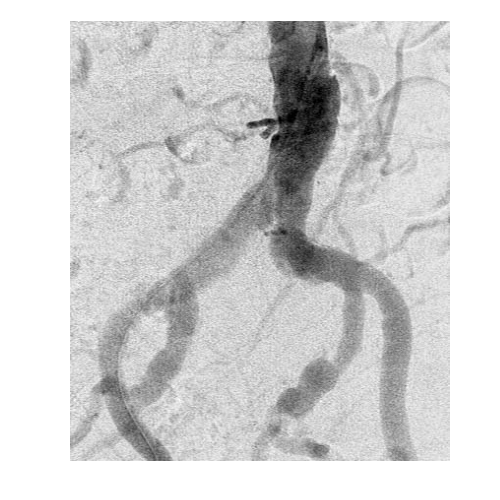

Button(description='save', style=ButtonStyle())

In [14]:
import cv2

# Load the PNG image in grayscale
new_image_path = '/content/Dr.SAM/Dr.SAM/data/images/1.jpg'
new_image = cv2.imread(new_image_path)

# # Display the loaded image to ensure it's correct
# plt.imshow(new_image, cmap='gray')
# plt.title(f'Loaded Image: {new_image_path}')
# plt.show()

# Set the image for the point prompt demo and show the interactive segmentation tool
point_prompt_demo.set_image(new_image)
point_prompt_demo.show()

In [15]:
def auto_generate_prompts(image, initial_mask):
    """Generate prompts from vessel centerline"""
    skeleton = skeletonize(initial_mask > 0)
    dist_map = distance_transform_edt(initial_mask)

    # Select points along centerline with varying diameters
    coords = np.argwhere(skeleton)
    diameters = [dist_map[c[0], c[1]] for c in coords]

    # Sample points at stenosis (thin) and normal regions
    thin_idx = np.where(diameters < np.percentile(diameters, 25))[0]
    normal_idx = np.where(diameters > np.percentile(diameters, 50))[0]

    prompts = coords[thin_idx[::5]].tolist() + coords[normal_idx[::5]].tolist()
    return prompts[:10]  # Limit to 10 points
